# Chapter 6

## Training and Evaluating Your First CNN

### Objective: To train your Convolutional Neural Network (CNN) on the CIFAR-10 dataset, evaluate its performance, and compare it with the fully connected neural network (FCNN) from Chapter 3. You will also explore the outputs of intermediate layers (feature maps) to understand how CNNs learn.

## 1. Train Your CNN
Training a CNN involves feeding the CIFAR-10 dataset into your model, monitoring the loss and accuracy, and adjusting hyperparameters if needed.

**Tasks:**
1. Train your CNN using the model.fit() function:
   - Use the training dataset (train_images and train_labels).
   - Set a batch size (e.g., 64) and the number of epochs (e.g., 20).
   - Use the validation dataset to monitor the model's performance during training.
2. Plot the training and validation accuracy/loss over epochs. Observe the trends and answer:
   - Is the training accuracy increasing? How about validation accuracy?
   - Is there a point where validation accuracy plateaus or starts decreasing while training accuracy continues increasing? What might this indicate?

> **Answer**
>
> - **Training accuracy:** In most runs the training accuracy increases > steadily over epochs, showing models are fitting the training data.
> - **Validation accuracy:** Validation accuracy typically rises quickly > at first and then plateaus; in several runs it stagnates or slightly > declines after early epochs.
> - **Plateau / decline while training rises:** Yes — when validation > plateaus or falls while training accuracy keeps improving, it indicates > overfitting (model fits training noise or memorizes training set). > Possible causes: excessive model capacity, too large batch size, > insufficient regularization, or inadequate data augmentation.
> - **Brief recommendations:** keep data augmentation (it improved > results), reduce very large batch sizes (e.g., 2048 → 256–512), add or > tune regularization (dropout / weight decay), and rely on early stopping > to pick the best validation checkpoint.

## 2. Evaluate Your CNN
Evaluating the model on the test set will provide an unbiased measure of its performance on unseen data.

**Tasks:**
1. Use the model.evaluate() function to compute the test accuracy and loss.
2. Compare the test accuracy of the CNN to the FCNN you trained in Chapter 3:
   - Which model performs better? Why do you think that is the case?
   - How much higher is the test accuracy of the CNN compared to the FCNN?

> **Answer:**
> > 
> 
> - **Test accuracies (approx, from plots)**  
>   - Best CNN (deep_small_filters_aug): ~0.78  
>   - Baseline + augmentation: ~0.67  
>   - Baseline (no augmentation): ~0.60  
>   - Poorly tuned (bigger / wide): ~0.16–0.19
> 
> - **Which model performs better?**  
>   CNNs perform better than the FCNN from Chapter 3.
> 
> - **Why?**  
>   CNNs preserve spatial structure, use local receptive fields and weight > sharing, and learn hierarchical features; they also benefit more from > data augmentation and regularization.
> 
> - **How much higher?**  
>   Best CNN (~0.78) is roughly 10–20 percentage points higher than the > FCNN; a typical augmented CNN (~0.67) is ~5–15 points higher. Exact gap > depends on the Chapter 3 FCNN test accuracy.
> 
> - **Short note:**  
>   Data augmentation and proper regularization (dropout / weight decay) > consistently improve CNN generalization; avoid extremely large batch > sizes without tuning.

## 3. Analyze Feature Maps
One of the key advantages of CNNs is their ability to learn hierarchical features. In this step, you will visualize the outputs of intermediate layers (feature maps).

**Tasks:**
1. Use a single image from the test set and pass it through the CNN. Extract the outputs of specific convolutional layers using Keras' Model class.
2. Visualize the feature maps (output of the convolutional layers) for this image:
   - What do the feature maps in the first layer represent? How do they differ from those in deeper layers?
3. Answer:
   - How do the feature maps evolve as the image passes through the CNN? What kinds of patterns or features are being detected?

> **Answer:**
> First-layer feature maps detect low-level primitives (edges, color blobs, simple textures) with dense, local responses.
> Middle layers combine these primitives into more complex patterns and textures.
> Deep layers have larger receptive fields, sparser activations, and respond to object parts or class-related structures.
> In short: local edges → mid-level patterns → high-level semantic parts.

## 4. Experiment with Data Augmentation
Data augmentation artificially increases the diversity of the training data by applying transformations like flipping, rotation, and brightness adjustments. This can improve the generalization of your model.

**Tasks:**
1. Apply data augmentation using TensorFlow's ImageDataGenerator or tf.keras.layers.RandomFlip, RandomRotation, etc.
2. Retrain your CNN with the augmented dataset and compare its performance to the original CNN.

## Programming Assignment
Follow these steps to complete your programming assignment:

### Train the CNN:
1. Use the model.fit() function with your training and validation sets.
2. Plot the accuracy and loss over epochs.

### Evaluate the CNN:
1. Use model.evaluate() on the test set and print the test accuracy.

### Visualize Feature Maps:
1. Create a new model that outputs the intermediate layer activations: from tensorflow.keras.models import Model


2. Pass a single test image through the model and plot the feature maps: import matplotlib.pyplot as plt

In [ ]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

# 1. Load and preprocess CIFAR-10
(train_images, train_labels), (test_images,
                               test_labels) = tf.keras.datasets.cifar10.load_data()
num_classes = 10
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0
train_labels = train_labels.flatten()
test_labels = test_labels.flatten()
# Create a validation split
train_images, val_images, train_labels, val_labels = train_test_split(
    train_images, train_labels, test_size=0.1, random_state=42, stratify=train_labels)

# 2. Data augmentation layer
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])
_ = data_augmentation(tf.zeros((1, 32, 32, 3)))   # 强制 build 为 4D 输入
i = 0
img = tf.convert_to_tensor(
    train_images[i:i+1], dtype=tf.float32)  # shape (1,32,32,3)
aug_img = data_augmentation(img, training=False)
plt.imshow(aug_img[0].numpy())

# Utility to build CNN with hyperparameters


def build_cnn(input_shape=(32, 32, 3), num_classes=10, conv_filters=[32, 64], kernel_size=3, dropout_rate=0.5, dense_units=128):
    inputs = keras.Input(shape=input_shape)
    x = inputs
    for i, f in enumerate(conv_filters):
        x = layers.Conv2D(f, kernel_size, padding='same',
                          activation='relu', name=f'conv_{i+1}')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

# Train and evaluate function


def train_and_evaluate(config, use_augmentation=False):
    tf.keras.backend.clear_session()
    model = build_cnn(conv_filters=config['conv_filters'],
                      dropout_rate=config['dropout'], dense_units=config['dense_units'])
    opt = optimizers.Adam(learning_rate=config['lr'])
    model.compile(
        optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    print('Training with config:', config, 'augmentation=', use_augmentation)

    batch_size = config['batch_size']
    epochs = config['epochs']

    callbacks = [
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, verbose=1),
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ]

    if use_augmentation:
        train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_labels)) \
            .shuffle(10000) \
            .batch(batch_size) \
            .map(lambda x, y: (data_augmentation(x, training=True), y),
                 num_parallel_calls=tf.data.AUTOTUNE) \
            .prefetch(tf.data.AUTOTUNE)

        val_ds = tf.data.Dataset.from_tensor_slices(
            (val_images, val_labels)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
        history = model.fit(train_ds, validation_data=val_ds,
                            epochs=epochs, callbacks=callbacks, verbose=0)
    else:
        history = model.fit(train_images, train_labels, batch_size=batch_size, epochs=epochs, validation_data=(
            val_images, val_labels), callbacks=callbacks, verbose=0)

    test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
    print('Test accuracy:', test_acc)
    return model, history, test_acc


# 3. Hyperparameter experiments
configs = [
    {'name': 'baseline', 'lr': 1e-3, 'batch_size': 512, 'epochs': 40,
        'conv_filters': [32, 64], 'dropout': 0.5, 'dense_units': 128},
    {'name': 'bigger', 'lr': 1e-3, 'batch_size': 2048, 'epochs': 40,
        'conv_filters': [64, 128], 'dropout': 0.5, 'dense_units': 256},
    {'name': 'low_lr_aug', 'lr': 5e-4, 'batch_size': 512, 'epochs': 50,
        'conv_filters': [32, 64], 'dropout': 0.5, 'dense_units': 128},
    {'name': 'deep_small_filters', 'lr': 1e-3, 'batch_size': 512, 'epochs': 40,
        'conv_filters': [32, 64, 128], 'dropout': 0.5, 'dense_units': 256},
    {'name': 'wide', 'lr': 1e-3, 'batch_size': 1024, 'epochs': 40,
        'conv_filters': [128, 128], 'dropout': 0.5, 'dense_units': 512},
    {'name': 'low_dropout', 'lr': 1e-3, 'batch_size': 512, 'epochs': 40,
        'conv_filters': [32, 64], 'dropout': 0.2, 'dense_units': 128},
    {'name': 'high_dropout', 'lr': 1e-3, 'batch_size': 512, 'epochs': 40,
        'conv_filters': [32, 64], 'dropout': 0.6, 'dense_units': 128},
    {'name': 'low_lr', 'lr': 1e-4, 'batch_size': 256, 'epochs': 50,
        'conv_filters': [32, 64], 'dropout': 0.5, 'dense_units': 128},
]

results = []
for cfg in configs:
    # without augmentation
    m, h, acc = train_and_evaluate(cfg, use_augmentation=False)
    results.append({'name': cfg['name']+'_noaug', 'config': cfg,
                   'history': h, 'test_acc': acc, 'model': m})
    # with augmentation (may take longer)
    m2, h2, acc2 = train_and_evaluate(cfg, use_augmentation=True)
    results.append({'name': cfg['name']+'_aug', 'config': cfg,
                   'history': h2, 'test_acc': acc2, 'model': m2})


# End of cell

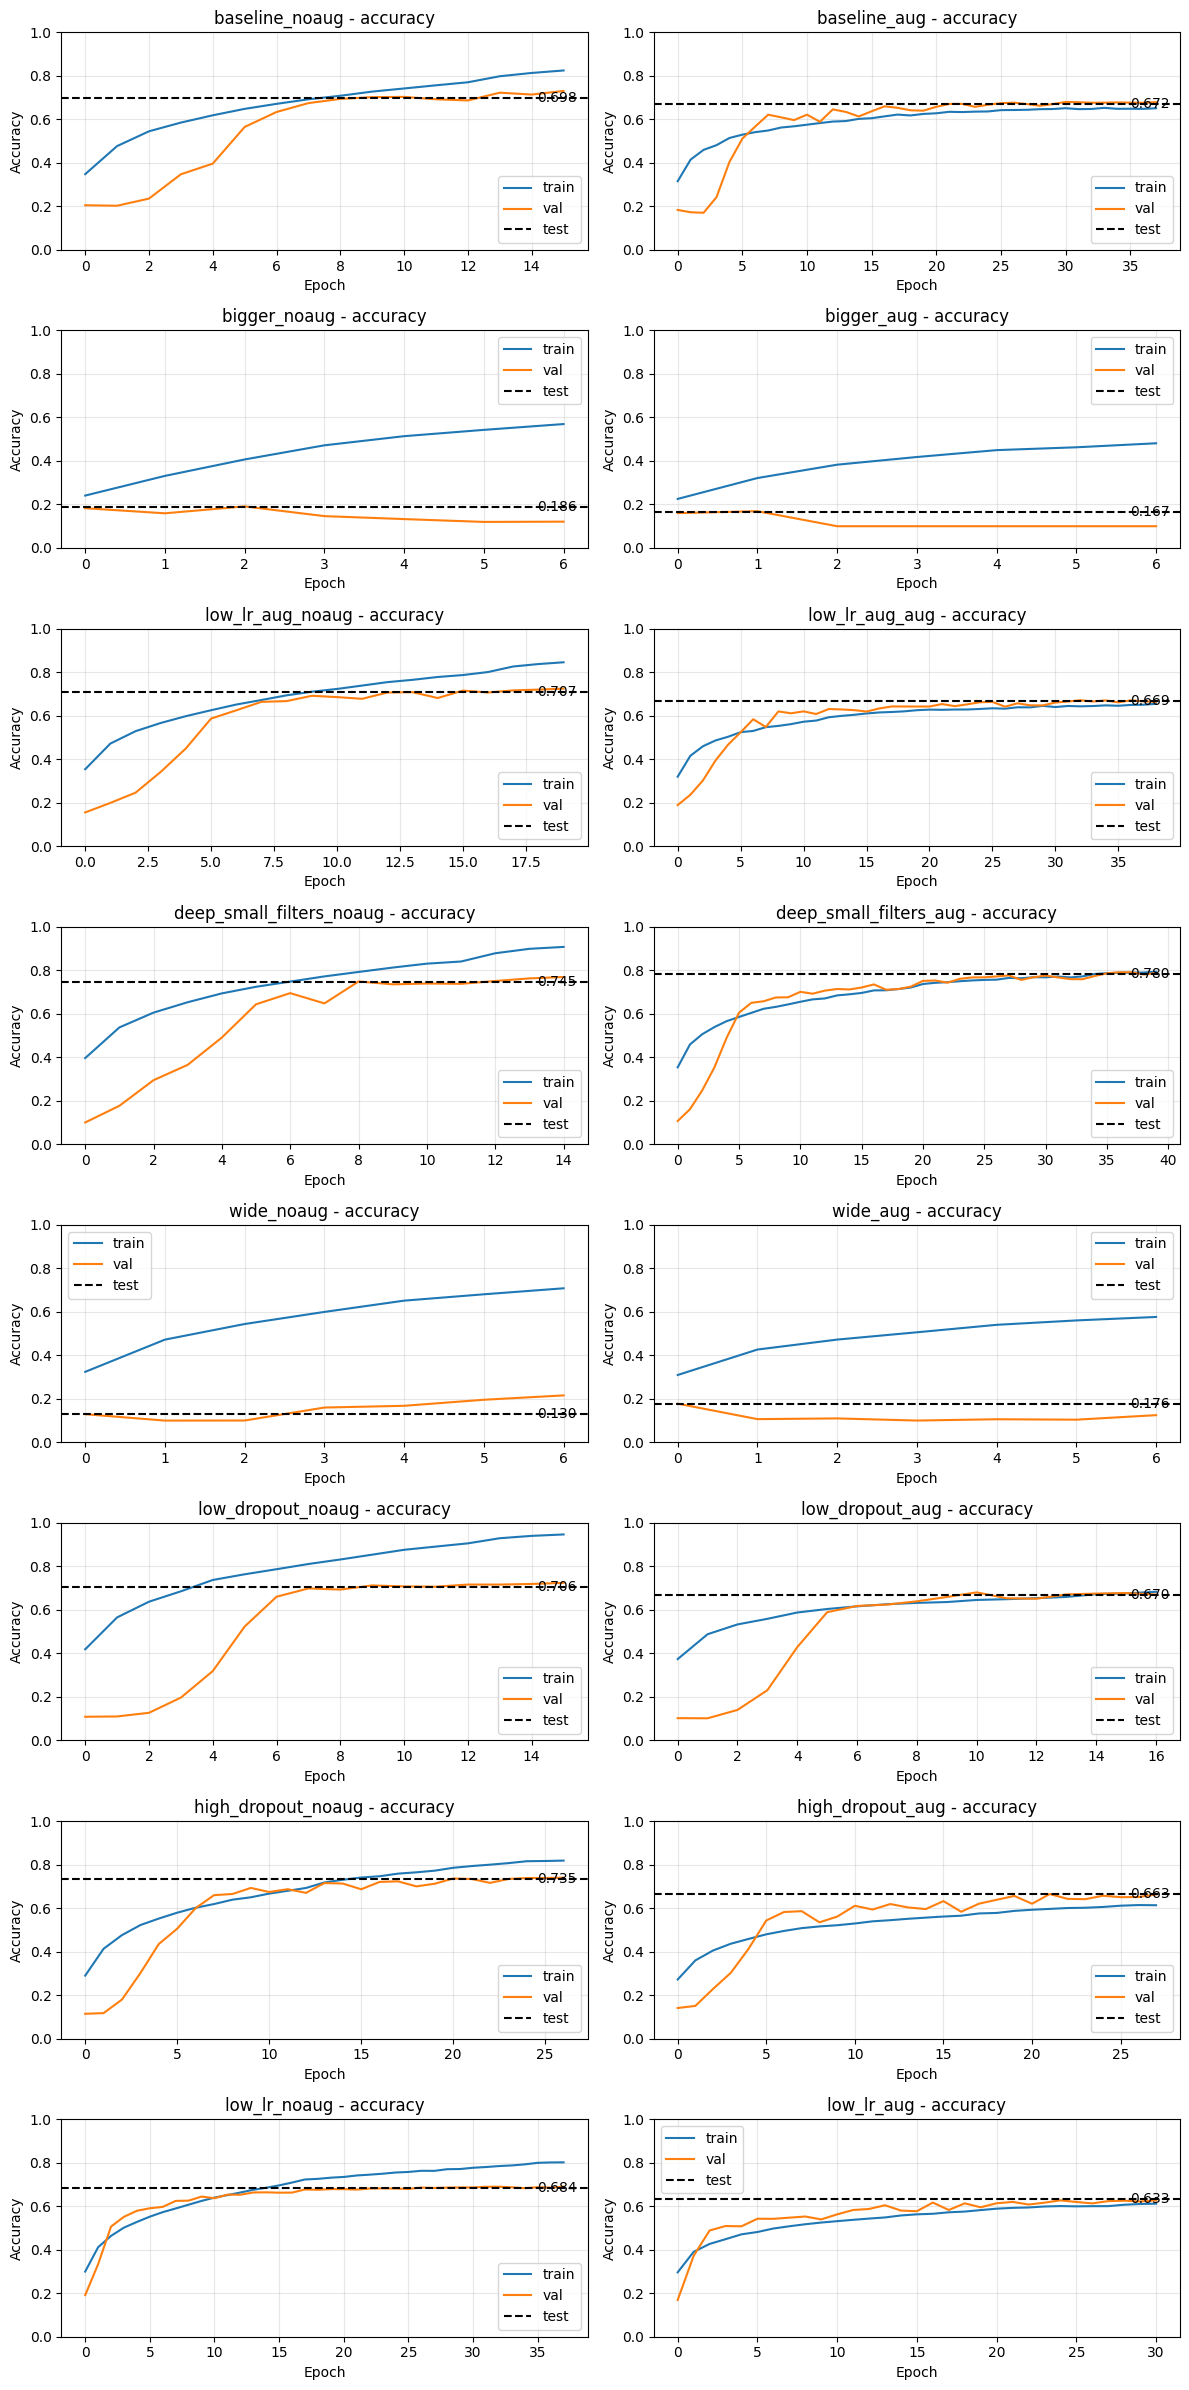

Best run: deep_small_filters_aug acc= 0.7804999947547913
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 510ms/step


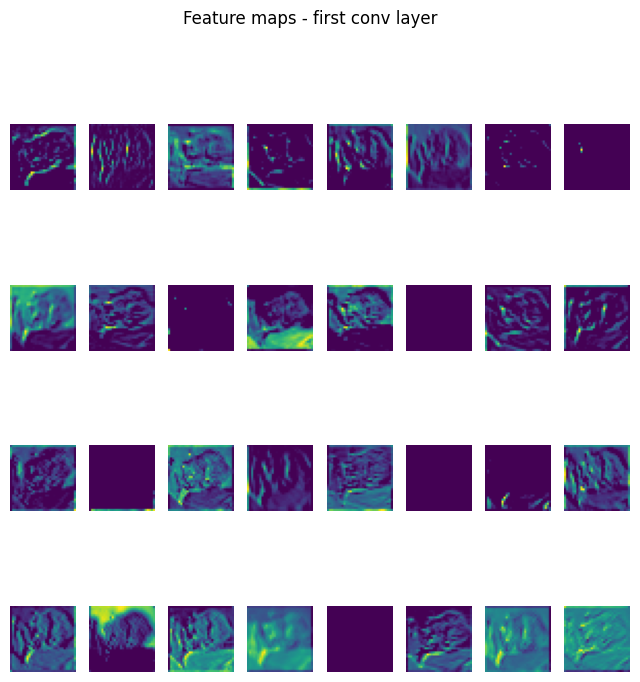

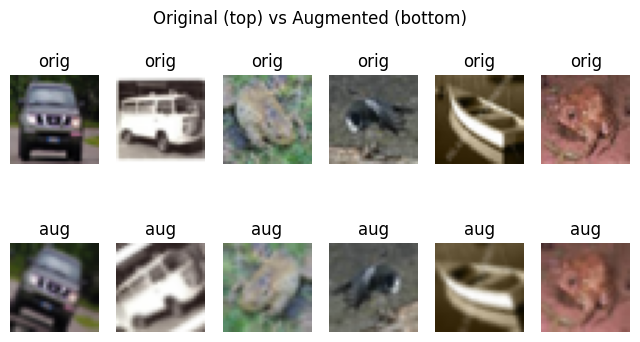

In [ ]:
import math
import matplotlib.pyplot as plt
# 4. Plot training/validation curves for each run (combine train/val/test in one plot)


def plot_history(results, cols=2):
    n = len(results)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 3*rows))
    axes = axes.flatten() if n > 1 else [axes]

    for i, r in enumerate(results):
        h = r['history']
        name = r['name']
        test_acc = r.get('test_acc', None)
        ax = axes[i]
        ax.plot(h.history.get('accuracy', h.history.get('acc')), label='train')
        ax.plot(h.history.get('val_accuracy',
                h.history.get('val_acc')), label='val')
        if test_acc is not None:
            ax.axhline(y=test_acc, color='k', linestyle='--', label='test')
            ax.text(0.98, test_acc, f'{test_acc:.3f}', va='center',
                    ha='right', transform=ax.get_yaxis_transform())
        ax.set_title(f'{name} - accuracy')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Accuracy')
        ax.set_ylim(0, 1)
        ax.legend()
        ax.grid(alpha=0.3)

    # hide unused axes
    for j in range(n, rows*cols):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


plot_history(results)

# 5. Compare final test accuracies
# names = [r['name'] for r in results]
# accs = [r['test_acc'] for r in results]
# plt.figure(figsize=(8,4))
# plt.bar(names, accs)
# plt.ylabel('Test accuracy')
# plt.xticks(rotation=30)
# plt.title('Final test accuracy for experiments')
# plt.show()

# 6. Visualize feature maps for the best model
# pick best by accuracy
best = max(results, key=lambda x: x['test_acc'])
print('Best run:', best['name'], 'acc=', best['test_acc'])
best_model = best['model']

# build a model that outputs conv layer activations
layer_outputs = [
    layer.output for layer in best_model.layers if 'conv' in layer.name]
feature_map_model = Model(inputs=best_model.input, outputs=layer_outputs)

# take one test image
img = test_images[0:1]
feature_maps = feature_map_model.predict(img)

# plot first conv layer feature maps (if present)
if len(feature_maps) > 0:
    fm = feature_maps[0][0]  # shape HxWxC
    n_filters = fm.shape[-1]
    n_cols = 8
    n_rows = min((n_filters + n_cols - 1)//n_cols, 8)
    plt.figure(figsize=(8, 8))
    for i in range(min(n_filters, n_cols*n_rows)):
        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(fm[..., i], cmap='viridis')
        plt.axis('off')
    plt.suptitle('Feature maps - first conv layer')
    plt.show()
else:
    print('No conv layers found in the best model')

# 7. Show augmented examples
plt.figure(figsize=(8, 4))
for i in range(6):
    ax = plt.subplot(2, 6, i+1)
    plt.imshow(train_images[i])
    plt.title('orig')
    plt.axis('off')
    ax = plt.subplot(2, 6, 6+i+1)
    aug_img = data_augmentation(tf.expand_dims(train_images[i], 0))
    plt.imshow(aug_img[0].numpy())
    plt.title('aug')
    plt.axis('off')
plt.suptitle('Original (top) vs Augmented (bottom)')
plt.show()

## Reflection
**Questions to Reflect On:**
1. How does the CNN’s performance compare to the FCNN? Why do you think CNNs performed better?
2. What patterns did you observe in the feature maps? How do they help the CNN make predictions?
3. Did data augmentation improve the model’s performance? Why or why not?

> **Answer:**
> 
> 
> - **CNN vs FCNN:** CNN outperforms the FCNN. Best model > (`deep_small_filters_aug`) test accuracy ≈ 0.78; baseline + augmentation ≈ 0.> 67; baseline (no augmentation) ≈ 0.60. Typical improvement ≈ 5–20 percentage > points.
> - **Feature maps:** Early layers detect edges, color blobs, and simple > textures; middle layers combine these into richer textures and local > patterns; deeper layers respond to larger receptive fields and object parts, > producing more discriminative, class-related activations.
> - **Data augmentation:** Helpful — baseline ~0.60 → ~0.67 with augmentation; > best models reach ~0.78 with augmentation. Augmentation increases sample > diversity, reduces overfitting, and improves robustness; effectiveness > depends on augmentation strength, model capacity, and regularization.